# Lesson 06: Probability & Distributions - Exercises

> Practice scaffold for the 4 exercises in **docs/en.md**. Each exercise contains only the skeleton/signature and a verification test cell. Implement the functions from scratch without using pre-packaged statistical solutions.



### Setup & Imports


In [1]:
import math
import random
import matplotlib.pyplot as plt

random.seed(42)
print("Setup complete. Seed set to 42.")


Setup complete. Seed set to 42.


## Exercise 1: Inverse Transform Sampling for Exponential Distribution

**Objective:**
1. Implement inverse transform sampling for the Exponential distribution with rate parameter $\lambda$ (`lam`).
2. Implement the true theoretical PDF: $f(x) = \lambda e^{-\lambda x}$ for $x \ge 0$.
3. Draw 10,000 samples and compare the empirical histogram with the theoretical curve.



Sampled 10000 values.
Sample Mean: 0.6663 (Theoretical: 0.6667)


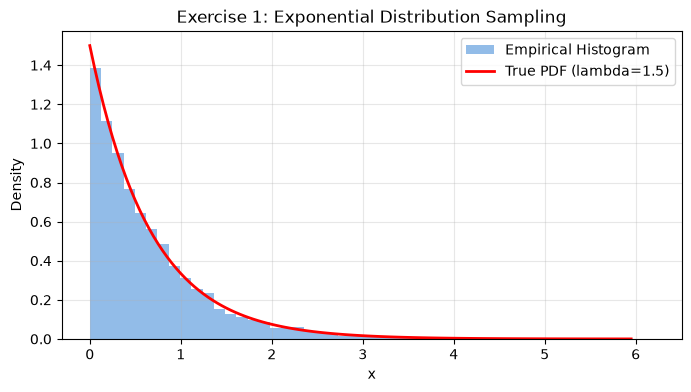

In [2]:
def sample_exponential(lam: float, n: int = 1) -> list[float]:
    """
    Draw n independent samples from Exponential(lambda) using inverse transform sampling.
    
    Parameters:
        lam: Rate parameter (lambda > 0).
        n: Number of samples to generate.
        
    Returns:
        List of n sampled float values.
    """
    samples = []
    for i in range(n): 
        u = random.random()
        x = -math.log(1-u) / lam
        samples.append(x)
    return samples


def exponential_pdf(x: float, lam: float) -> float:
    """
    Theoretical Probability Density Function (PDF) of Exponential(lambda).
    f(x) = lambda * exp(-lambda * x) for x >= 0, else 0.0.
    """
    return (lam * math.exp(-lam * x )) if (x >= 0) else 0.0


# ==============================================================================
# Verification / Test for Exercise 1
# ==============================================================================
lam = 1.5
n_samples = 10000

samples = sample_exponential(lam, n_samples)

if samples is not None:
    print(f"Sampled {len(samples)} values.")
    print(f"Sample Mean: {sum(samples)/len(samples):.4f} (Theoretical: {1/lam:.4f})")
    
    # Plot histogram vs theoretical PDF
    plt.figure(figsize=(8, 4))
    plt.hist(samples, bins=50, density=True, alpha=0.6, color="#4a90d9", label="Empirical Histogram")
    xs = [i * 0.05 for i in range(120)]
    ys = [exponential_pdf(x, lam) for x in xs]
    plt.plot(xs, ys, color="red", linewidth=2, label=f"True PDF (lambda={lam})")
    plt.title("Exercise 1: Exponential Distribution Sampling")
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("sample_exponential returned None. Implement the function above!")



## Exercise 2: Joint Distribution for Two Loaded Dice & Independence

**Objective:**
1. Given probability distributions for two loaded 6-sided dice, build their $6 \times 6$ joint distribution table.
2. Compute marginal distributions $P(\text{Die}_1)$ and $P(\text{Die}_2)$.
3. Check whether the two dice are statistically independent: $P(\text{Die}_1 = i, \text{Die}_2 = j) = P(\text{Die}_1 = i) \cdot P(\text{Die}_2 = j)$.


In [1]:
def build_joint_distribution(p_die1: list[float], p_die2: list[float]) -> list[list[float]]:
    """
    Build the 6x6 joint PMF table for two independent rolls of loaded dice.
    
    Parameters:
        p_die1: List of 6 probabilities for Die 1 (summing to 1.0).
        p_die2: List of 6 probabilities for Die 2 (summing to 1.0).
        
    Returns:
        6x6 2D matrix where joint[i][j] = P(Die1 = i + 1, Die2 = j + 1).
    """
    joint = []

    for i in range(len(p_die1)):
        row = []
        for j in range(len(p_die2)): 
            row.append(p_die1[i] * p_die2[j])
        joint.append(row)
    return joint


def compute_marginals(joint: list[list[float]]) -> tuple[list[float], list[float]]:
    """
    Compute marginal distributions from a 2D joint probability matrix.
    
    Returns:
        tuple (marginal_die1, marginal_die2) representing row sums and column sums.
    """
    marginal_die1 = []
    marginal_die2 = []
    for i in range(len(joint)): 
        marginal_die1.append(sum(joint[i]))
        marginal_die2.append(sum([joint[j][i] for j in range(len(joint))]))
    return marginal_die1, marginal_die2


def check_independence(joint: list[list[float]], marginal_1: list[float], marginal_2: list[float], tol: float = 1e-9) -> bool:
    """
    Verify if P(X=i, Y=j) == P(X=i) * P(Y=j) for all cells within tolerance tol.
    """
    for i in range(len(joint)):
        for j in range(len(joint)): 
            if abs(joint[i][j] - marginal_1[i] * marginal_2[j]) >= tol: return False
    return True


# ==============================================================================
# Verification / Test for Exercise 2
# ==============================================================================
# Define probabilities for two loaded dice
p_loaded_1 = [0.1, 0.1, 0.1, 0.2, 0.2, 0.3]
p_loaded_2 = [0.05, 0.05, 0.1, 0.2, 0.3, 0.3]

joint_table = build_joint_distribution(p_loaded_1, p_loaded_2)

if joint_table is not None:
    m1, m2 = compute_marginals(joint_table)
    print("Marginal Die 1:", [round(p, 4) for p in m1])
    print("Expected Die 1:", p_loaded_1)
    print("Marginal Die 2:", [round(p, 4) for p in m2])
    print("Expected Die 2:", p_loaded_2)
    is_indep = check_independence(joint_table, m1, m2)
    print("Are dice independent?:", is_indep, "(Expected: True)")
else:
    print("build_joint_distribution returned None. Implement the functions above!")


Marginal Die 1: [0.1, 0.1, 0.1, 0.2, 0.2, 0.3]
Expected Die 1: [0.1, 0.1, 0.1, 0.2, 0.2, 0.3]
Marginal Die 2: [0.05, 0.05, 0.1, 0.2, 0.3, 0.3]
Expected Die 2: [0.05, 0.05, 0.1, 0.2, 0.3, 0.3]
Are dice independent?: True (Expected: True)


## Exercise 3: Cross-Entropy Loss & PyTorch Verification

**Objective:**
1. Compute multi-class Cross-Entropy loss from scratch for logits `[2.0, 0.5, -1.0, 3.0, 0.1]` when target class index is 3.
2. Verify that your scratch implementation matches PyTorch's `torch.nn.CrossEntropyLoss`.



In [12]:
def cross_entropy_loss_scratch(logits: list[float], target_index: int) -> float:
    """
    Compute Cross-Entropy Loss from raw logits using numerically stable Log-Softmax.
    
    Parameters:
        logits: Raw unnormalized class scores.
        target_index: Index of the true ground-truth class.
        
    Returns:
        Loss scalar: -log(P(target_class)).
    """
    max_logits = max(logits)
    
    prob_target = math.exp(logits[target_index] - max_logits) / sum( [math.exp(z - max_logits) for z in logits ] )

    return -math.log(prob_target) 
    

    
    


# ==============================================================================
# Verification / Test for Exercise 3
# ==============================================================================
test_logits = [2.0, 0.5, -1.0, 3.0, 0.1]
target_idx = 3

loss_scratch = cross_entropy_loss_scratch(test_logits, target_idx)

print(f"Scratch Cross-Entropy Loss: {loss_scratch}")

try:
    import torch
    import torch.nn as nn
    
    loss_fn = nn.CrossEntropyLoss()
    logits_tensor = torch.tensor([test_logits], dtype=torch.float32)
    target_tensor = torch.tensor([target_idx], dtype=torch.long)
    torch_loss = loss_fn(logits_tensor, target_tensor).item()
    
    print(f"PyTorch nn.CrossEntropyLoss: {torch_loss:.6f}")
    if loss_scratch is not None:
        diff = abs(loss_scratch - torch_loss)
        print(f"Absolute Difference: {diff:.2e} (Match: {diff < 1e-6})")
except ImportError:
    print("PyTorch not installed in environment, run: pip install torch")



Scratch Cross-Entropy Loss: 0.42088119968071197
PyTorch nn.CrossEntropyLoss: 0.420881
Absolute Difference: 1.77e-08 (Match: True)


## Exercise 4: Most Likely Sequence & Sequence Log Probabilities

**Objective (from docs/en.md):**
Write a function that takes candidate sequences of log probabilities (or a sequence of log probabilities) and returns:
1. **The most likely sequence** (the candidate sequence with the highest total log probability).
2. **The total log probability** (sum of log probabilities: $\sum \ln(P(w_i))$).
3. **The equivalent raw probability** (converted back: $\exp(\text{total\_log\_prob})$).

Test it with a sentence of 50 words where each word has probability $0.01$.


In [15]:

from math import inf
def find_most_likely_sequence(candidates: dict[str, list[float]] | list[list[float]] | list[float]) -> tuple:
    """
    Given candidate sequences of log probabilities (or a single sequence of log probabilities),
    find the most likely sequence, its total log probability, and the equivalent raw probability.
    
    Parameters:
        candidates: Can be:
            - A dict: {"sequence_name": [log_p1, log_p2, ...], ...}
            - A list of candidate sequences: [[log_p1, log_p2, ...], ...]
            - A single sequence of log probabilities: [log_p1, log_p2, ...]
            
    Returns:
        tuple: (most_likely_sequence, total_log_probability, equivalent_raw_probability)
    """
    best = None
    highest = -math.inf
    for key, value in candidates.items(): 
        if (sum(value) >  highest): 
            best = key
            highest = sum(value)

    
    return (best, highest, math.exp(highest))



# ==============================================================================
# Verification / Test for Exercise 4
# ==============================================================================
# 1. Test with a sentence of 50 words where each word has probability 0.01
word_prob = 0.01
n_words = 50
sentence_log_probs = [math.log(word_prob)] * n_words

result_single = find_most_likely_sequence({"Sentence 50 words": sentence_log_probs})
if result_single is not None:
    seq, total_log, raw_prob = result_single
    print("--- Test 1: Single 50-word Sentence (p=0.01 per word) ---")
    print(f"Total Log Probability:    {total_log:.4f} (Expected: ~ -230.2585)")
    print(f"Equivalent Raw Prob (exp): {raw_prob:.2e} (Expected: ~ 1.00e-100)")
    
    # 2. Test selecting the most likely sequence among candidates
    candidates = {
        "Candidate A (50 words with p=0.01)": [math.log(0.01)] * 50,
        "Candidate B (50 words with p=0.05)": [math.log(0.05)] * 50,
    }
    best_seq, best_log, best_raw = find_most_likely_sequence(candidates)
    print("\n--- Test 2: Selecting Most Likely Candidate ---")
    print(f"Most Likely Sequence:     {best_seq}")
    print(f"Best Total Log Prob:      {best_log:.4f}")
    print(f"Best Equivalent Raw Prob: {best_raw:.2e}")
else:
    print("find_most_likely_sequence returned None. Implement the function above!")


--- Test 1: Single 50-word Sentence (p=0.01 per word) ---
Total Log Probability:    -230.2585 (Expected: ~ -230.2585)
Equivalent Raw Prob (exp): 1.00e-100 (Expected: ~ 1.00e-100)

--- Test 2: Selecting Most Likely Candidate ---
Most Likely Sequence:     Candidate B (50 words with p=0.05)
Best Total Log Prob:      -149.7866
Best Equivalent Raw Prob: 8.88e-66
